In [72]:
import numpy as np
from spidercat.generate import density_lower_bound


def minimum_E_and_V(n, t):
    density = density_lower_bound(t)
    E_nec = np.ceil(n / density).astype(int)
    remainder = E_nec % 3
    adjustment = (3 - remainder) % 3
    E_final = E_nec + adjustment
    V_final = (2 * E_final) // 3
    return E_final.tolist(), V_final.tolist()

n, t = 10, 4
T_cut = min(t, (np.floor(n / 2) - 1).astype(int))
T_mark = 2 * t - 1

print(T_cut, T_mark)

num_edges, num_vertices = minimum_E_and_V(n, T_mark)
print(num_edges, num_vertices)

4 7
18 12


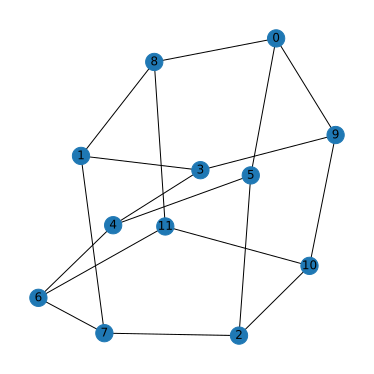

In [73]:
from spidercat.graphs_random import generate_3regular_graph_with_no_nonlocal_t_cut
from spidercat.draw import visualize_cat_state_base, draw_spanning_forest_solution

G = generate_3regular_graph_with_no_nonlocal_t_cut(num_vertices, T_cut)
visualize_cat_state_base(G, [], {})

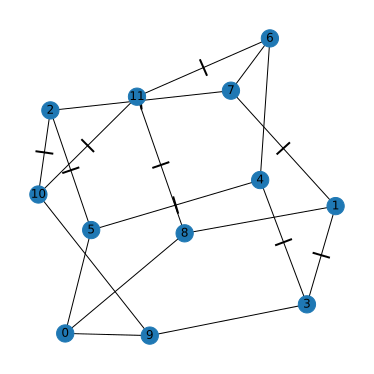

In [75]:
from spidercat.markings import GraphMarker

marker = GraphMarker(G, max_marks=n)
marks = marker.find_solution(T_mark)

visualize_cat_state_base(G, [], marks)

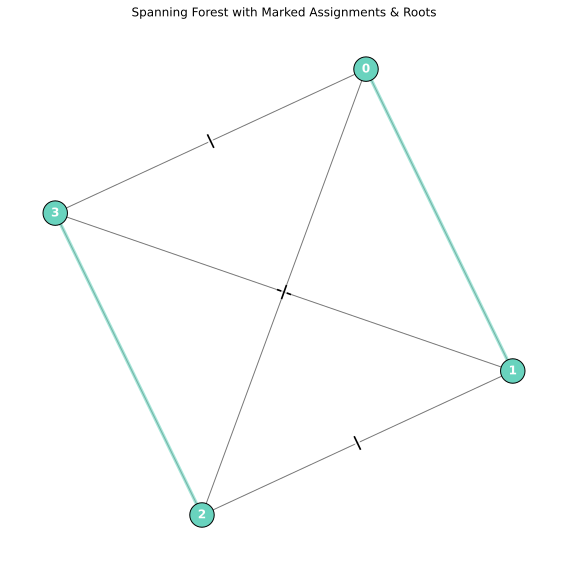

In [14]:
from spidercat.spanning_tree import build_trivial_spanning_forest, build_min_diameter_spanning_tree

forest = build_trivial_spanning_forest(G, marks)
draw_spanning_forest_solution(G, forest, marks, figsize=(8,8))

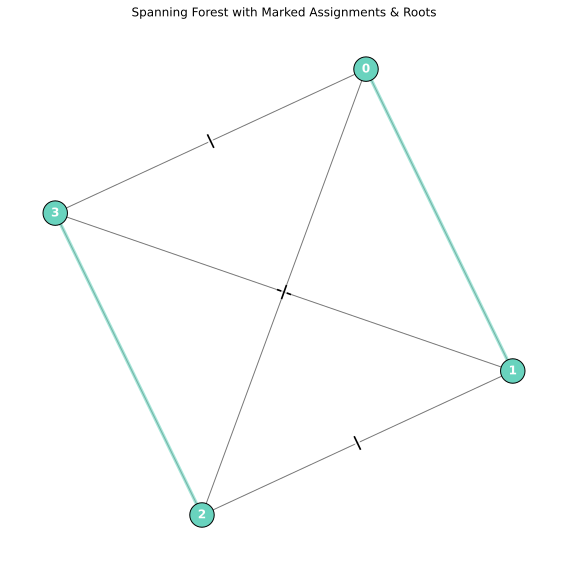

In [15]:
tree = build_min_diameter_spanning_tree(G, forest, marks, 4)
draw_spanning_forest_solution(G, tree, marks, figsize=(8,8))

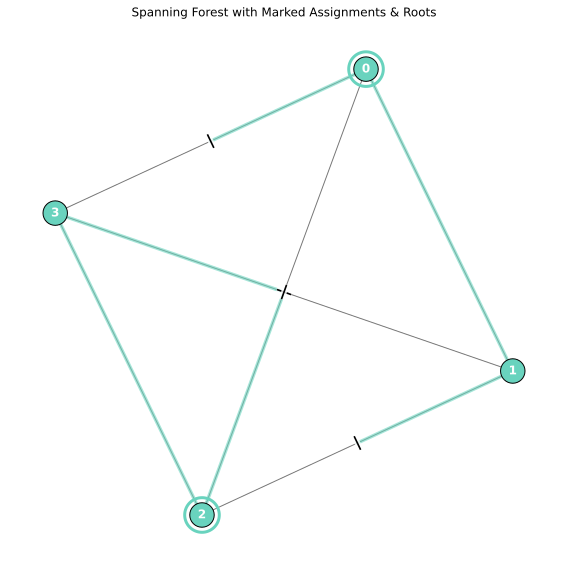

In [16]:
from spidercat.spanning_tree import match_forest_leaves_to_marked_edges, find_min_height_roots

matchings = match_forest_leaves_to_marked_edges(G, tree, marks)
roots = find_min_height_roots(tree)
draw_spanning_forest_solution(G, tree, marks, matchings, roots, figsize=(8,8))

=== Starting Elegant Extraction (BFS) ===
Init Root 0 (Tree 0) -> Q0
Init Root 2 (Tree 2) -> Q1
  New flag initialised (0, 5): CNOT Q0 -> Q4
  Node 0 -> Branch 1: Spawned CNOT Q0 -> Q2
  Node 0 -> Primary 4 (Inherits Q0)
  New flag initialised (2, 6): CNOT Q1 -> Q5
  Node 2 -> Branch 3: Spawned CNOT Q1 -> Q3
  Node 2 -> Primary 5 (Inherits Q1)
  New flag initialised (1, 7): CNOT Q2 -> Q6
  Node 1 -> Primary 6 (Inherits Q2)
  New flag initialised (4, 3): CNOT Q0 -> Q7
  Node 4 serves as a sink point for Q0
  Flag (3, 4) finalised: CNOT Q3 -> Q7; PostSelect_Z 7
  Node 3 -> Primary 7 (Inherits Q3)
  Flag (5, 0) finalised: CNOT Q1 -> Q4; PostSelect_Z 4
  Node 5 serves as a sink point for Q1
  Flag (6, 2) finalised: CNOT Q2 -> Q5; PostSelect_Z 5
  Node 6 serves as a sink point for Q2
  Flag (7, 1) finalised: CNOT Q3 -> Q6; PostSelect_Z 6
  Node 7 serves as a sink point for Q3
Generating Detectors...


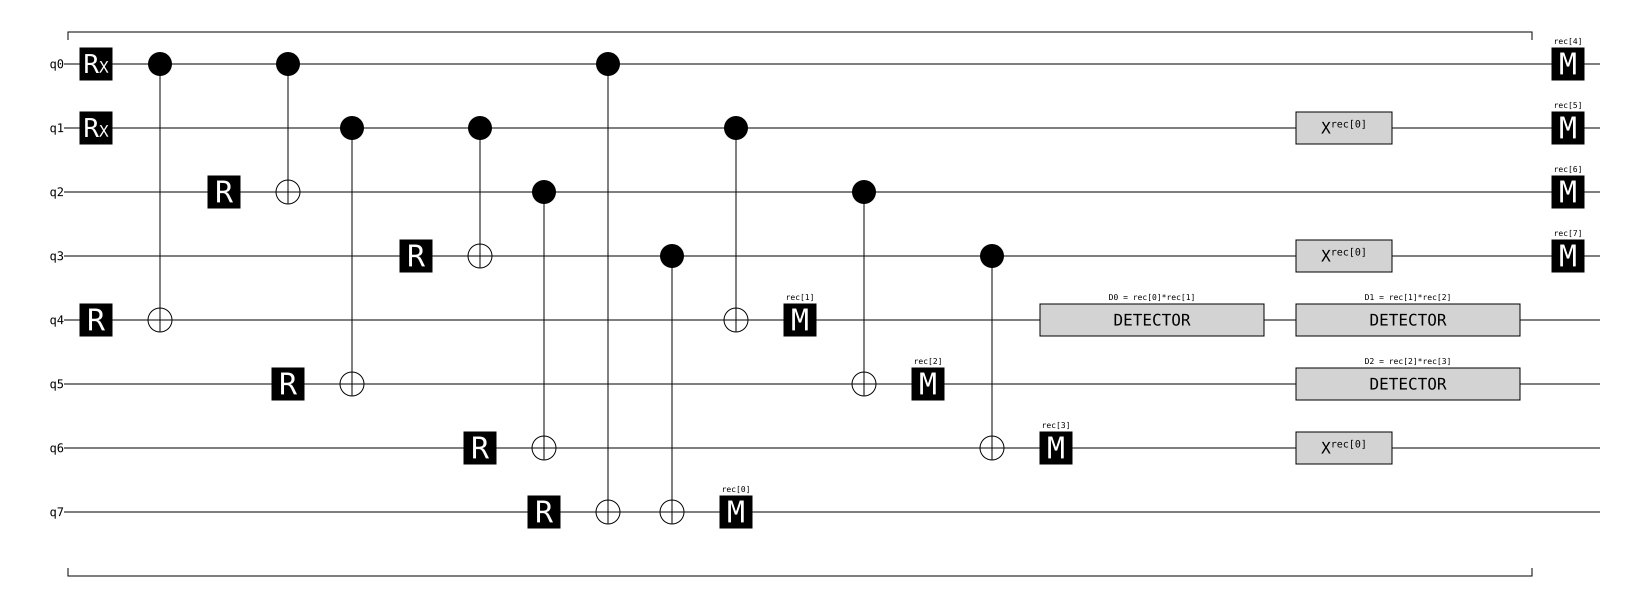

In [17]:
from spidercat.circuit_extraction import extract_circuit_rooted

circ = extract_circuit_rooted(G, tree, roots, marks, matchings, verbose=True)
circ.append("TICK", [])
circ.append("M", range(n))
circ.diagram('timeline-svg')

In [18]:
samples = circ.compile_sampler().sample(10)
converter = circ.compile_m2d_converter()

print(samples[:,-n:].astype(int))
l, d = converter.convert(measurements=samples, separate_observables=True)
print()
print(samples[:,:-n].astype(int))

[[0 0 0 0]
 [0 0 0 0]
 [1 1 1 1]
 [0 0 0 0]
 [1 1 1 1]
 [0 0 0 0]
 [1 1 1 1]
 [1 1 1 1]
 [0 0 0 0]
 [0 0 0 0]]

[[1 1 1 1]
 [0 0 0 0]
 [0 0 0 0]
 [1 1 1 1]
 [1 1 1 1]
 [1 1 1 1]
 [1 1 1 1]
 [0 0 0 0]
 [1 1 1 1]
 [0 0 0 0]]
